# Electrode Correlations

## Step 0: Imports and Settings

In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
from scipy.stats import pearsonr

preprocessed_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
raw_data_root = Path('/Users/rustin/Documents/Big Data 567/faces_basic/data')
lambda_width = 20.0
ridge = 1.0
holdout_pid = 'aa'
coord_round_decimals = 3
random_seed = 7


## Step 1: Per-Subject Correlations

For subject $s$ with matrix $X_s$ (samples $\times$ electrodes):

$$C_s = \mathrm{corr}(X_s)$$

In [30]:
def zscore_cols(x, eps=1e-6):
    x = np.asarray(x, dtype=np.float32)
    mu = x.mean(axis=0, keepdims=True)
    sd = x.std(axis=0, keepdims=True)
    sd[sd < eps] = 1.0
    return (x - mu) / sd


def coord_key(coord, decimals=3):
    return tuple(np.round(np.asarray(coord, dtype=np.float32), decimals).tolist())


def row_normalize(W, eps=1e-12):
    W = np.asarray(W, dtype=np.float32)
    s = W.sum(axis=1)
    out = np.zeros_like(W, dtype=np.float32)
    valid = s > eps
    out[valid] = W[valid] / s[valid, None]
    return out


def corrcoef_cols(X):
    C = np.corrcoef(np.asarray(X, dtype=np.float32), rowvar=False)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    C = np.clip(C, -1.0, 1.0)
    np.fill_diagonal(C, 1.0)
    return C


def fisher_z(x):
    x = np.asarray(x, dtype=np.float32)
    x = np.clip(x, -0.999999, 0.999999)
    return np.arctanh(x)


def inverse_fisher_z(z):
    return np.tanh(z)


def safe_corr(x, y):
    if np.std(x) < 1e-8 or np.std(y) < 1e-8:
        return np.nan
    return pearsonr(x, y).statistic


In [31]:
# goes through the file containing the preprocessed subjects and loads them into a dictionary
# z scores the data

npz_files = sorted(preprocessed_dir.glob('*_preprocessed.npz'))
subject_records = {}
for f in npz_files:
    pid = f.stem.replace('_preprocessed', '')
    rec = np.load(f, allow_pickle=True)
    ecog = np.asarray(rec['ecog'], dtype=np.float32)
    ecog_z = zscore_cols(ecog)
    locs = np.asarray(rec['locs_mni_mm'], dtype=np.float32)

    subject_records[pid] = {
        'locs': locs,
        'X_common': ecog_z,
    }

print('subjects:', sorted(subject_records.keys()))
for pid in sorted(subject_records.keys()):
    print(f'  {pid}: X shape={subject_records[pid]["X_common"].shape}')

# output is key : "aa"
# values are locs (np.array), X_common (np.array)


subjects: ['aa', 'ap', 'ca', 'de', 'fp', 'ha', 'ja', 'jt', 'mv', 'rn', 'rr', 'wc', 'zt']
  aa: X shape=(244200, 41)
  ap: X shape=(241200, 40)
  ca: X shape=(244200, 49)
  de: X shape=(244200, 31)
  fp: X shape=(244200, 11)
  ha: X shape=(242200, 39)
  ja: X shape=(244200, 37)
  jt: X shape=(244200, 96)
  mv: X shape=(244200, 19)
  rn: X shape=(244240, 41)
  rr: X shape=(162800, 40)
  wc: X shape=(244200, 38)
  zt: X shape=(244200, 58)


## Step 2: Gaussian Distance Weights

For pooled locations $r_i$ and subject electrode locations $\eta_j$:

$$W_s(i,j)=\exp\left(-\frac{\|r_i-\eta_j\|^2}{\lambda^2}\right)$$

Row-normalize each row of $W_s$.

In [32]:
# using the subject_records dictionary, builds a pooled electrode matrix

ordered_keys = [] # list where we store unique electrode coordinate keys in the order we first encounter them
seen = set() #have we already added this coordinate key?
for pid in sorted(subject_records.keys()):
    rec = subject_records[pid]
    for c in rec['locs']:
        k = coord_key(c, decimals=coord_round_decimals)
        if k not in seen:
            seen.add(k)
            ordered_keys.append(k)

pooled_keys = ordered_keys
all_electrodes = np.array(pooled_keys, dtype=np.float32)

for pid, rec in subject_records.items():
    locs = rec['locs']
    d2 = ((all_electrodes[:, None, :] - locs[None, :, :]) ** 2).sum(axis=2)
    W = np.exp(-d2 / lambda_width).astype(np.float32, copy=False)
    rec['W'] = W
    rec['pooled_idx'] = np.array([pooled_keys.index(coord_key(c, coord_round_decimals)) for c in locs], dtype=int)

print('pooled electrode count:', all_electrodes.shape[0])

pooled electrode count: 540


## Step 3A: Subject Full-Brain Correlation

$$\hat C_s = \tanh\left(\frac{W_s\,\operatorname{arctanh}(C_s)\,W_s^T}{W_s\,\mathbf{1}\,W_s^T}\right)$$

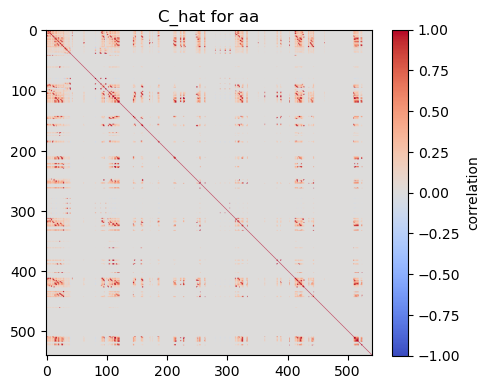

In [33]:
C_hat_s_matrices = {}
eps = 1e-12

for pid, rec in subject_records.items():
    C = corrcoef_cols(rec['X_common'])
    W = rec['W']

    Cz = fisher_z(C).astype(np.float32, copy=False)
    numerator = W @ Cz @ W.T
    denominator = W @ np.ones_like(Cz, dtype=np.float32) @ W.T

    mean_z = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator, dtype=np.float32),
        where=denominator > eps,
    )

    C_hat = inverse_fisher_z(mean_z).astype(np.float32, copy=False)
    C_hat = 0.5 * (C_hat + C_hat.T)
    np.fill_diagonal(C_hat, 1.0)

    rec['C'] = C
    rec['C_hat'] = C_hat
    C_hat_s_matrices[pid] = C_hat

example_pid = sorted(subject_records.keys())[0]
plt.figure(figsize=(5, 4))
plt.imshow(subject_records[example_pid]['C_hat'], cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='correlation')
plt.title(f'C_hat for {example_pid}')
plt.tight_layout()
plt.show()

## Step 3B: Across-Subject Average Correlation

$$\hat K = \tanh\left(\frac{1}{S}\sum_s \operatorname{arctanh}(\hat C_s)\right)$$

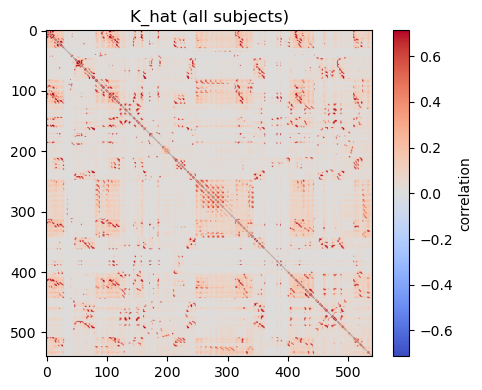

In [34]:
C_hat_stack = np.stack([subject_records[pid]['C_hat'] for pid in sorted(subject_records.keys())], axis=0)
K_hat = inverse_fisher_z(np.mean(fisher_z(C_hat_stack), axis=0))
K_hat = np.nan_to_num(K_hat, nan=0.0, posinf=0.0, neginf=0.0)
K_hat = 0.5 * (K_hat + K_hat.T)
np.fill_diagonal(K_hat, 1.0)

plt.figure(figsize=(5, 4))
K_hat_plot = K_hat.copy()
np.fill_diagonal(K_hat_plot, np.nan)
offdiag = K_hat[~np.eye(K_hat.shape[0], dtype=bool)]
v = float(np.nanpercentile(np.abs(offdiag), 99))
v = max(v, 1e-3)
plt.imshow(K_hat_plot, cmap='coolwarm', vmin=-v, vmax=v)
plt.colorbar(label='correlation')
plt.title('K_hat (all subjects)')
plt.tight_layout()
plt.show()

## Step 3C: Leakage-Free $K$ for Held-Out Subject

Exclude held-out subject from the average.

In [35]:
train_pids = [pid for pid in sorted(subject_records.keys()) if pid != holdout_pid]
C_hat_train = np.stack([subject_records[pid]['C_hat'] for pid in train_pids], axis=0)
K_hat_no_leak = inverse_fisher_z(np.mean(fisher_z(C_hat_train), axis=0))
K_hat_no_leak = np.nan_to_num(K_hat_no_leak, nan=0.0, posinf=0.0, neginf=0.0)
np.fill_diagonal(K_hat_no_leak, 1.0)
print('K_hat_no_leak shape:', K_hat_no_leak.shape)


K_hat_no_leak shape: (540, 540)


## Step 4: Single-Electrode Prediction

Split held-out subject electrodes into observed set $\alpha$ and held-out set $\beta$.

$$D = K_{\beta\alpha}(K_{\alpha\alpha}+\lambda I)^{-1}$$

$$\hat Y_{\beta} = D Y_{\alpha}$$

In [36]:
aa = subject_records[holdout_pid]
Y = aa['X_common']
pooled_idx = aa['pooled_idx']

beta_local_idx = np.array([0], dtype=int)
alpha_local_idx = np.array([i for i in range(Y.shape[1]) if i not in set(beta_local_idx)], dtype=int)

alpha_pooled_idx = pooled_idx[alpha_local_idx]
beta_pooled_idx = pooled_idx[beta_local_idx]

Kaa = K_hat_no_leak[np.ix_(alpha_pooled_idx, alpha_pooled_idx)]
Kba = K_hat_no_leak[np.ix_(beta_pooled_idx, alpha_pooled_idx)]

Kaa_sym = 0.5 * (Kaa + Kaa.T)
vals, vecs = np.linalg.eigh(Kaa_sym)
vals = np.clip(vals, 1e-6, None)
Kaa_psd = (vecs * vals) @ vecs.T
Kaa_reg = Kaa_psd + ridge * np.eye(Kaa_psd.shape[0], dtype=np.float32)

D = Kba @ np.linalg.pinv(Kaa_reg, rcond=1e-6)
Y_alpha = Y[:, alpha_local_idx]
Y_beta_true = Y[:, beta_local_idx]
Y_beta_pred = (D @ Y_alpha.T).T

r_single = safe_corr(Y_beta_true[:, 0], Y_beta_pred[:, 0])
print('single-electrode r:', r_single)


single-electrode r: 0.41302130645665347


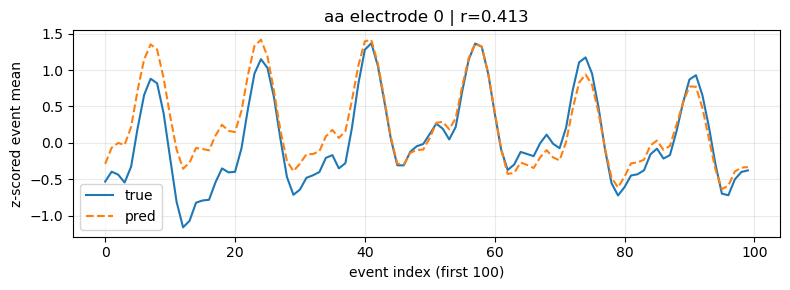

In [37]:
n_show = min(100, Y_beta_true.shape[0])
plt.figure(figsize=(8, 3))
plt.plot(np.arange(n_show), Y_beta_true[:n_show, 0], label='true')
plt.plot(np.arange(n_show), Y_beta_pred[:n_show, 0], label='pred', linestyle='--')
plt.title(f'{holdout_pid} electrode {beta_local_idx[0]} | r={r_single:.3f}')
plt.xlabel('event index (first 100)')
plt.ylabel('z-scored event mean')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Step 5: Multi-Electrode Prediction 
- w/ ridge regression

In [38]:
Y = subject_records[holdout_pid]['X_common']
pooled_idx = subject_records[holdout_pid]['pooled_idx']

manual_beta_local_idx = [0, 22, 30, 36]

n_elecs = Y.shape[1]

if len(manual_beta_local_idx) > 0:
    beta_local_idx = np.array(sorted(set(int(i) for i in manual_beta_local_idx)), dtype=int)
    if np.any(beta_local_idx < 0) or np.any(beta_local_idx >= n_elecs):
        raise ValueError(f'manual_beta_local_idx must be between 0 and {n_elecs-1}')
    if beta_local_idx.size >= n_elecs:
        raise ValueError('manual_beta_local_idx cannot include all electrodes')
else:
    rng = np.random.default_rng(random_seed)
    n_beta = max(1, n_elecs // 2)
    perm = rng.permutation(n_elecs)
    beta_local_idx = np.sort(perm[:n_beta])

alpha_local_idx = np.array([i for i in range(n_elecs) if i not in set(beta_local_idx)], dtype=int)

alpha_pooled_idx = pooled_idx[alpha_local_idx]
beta_pooled_idx = pooled_idx[beta_local_idx]

Kaa = K_hat_no_leak[np.ix_(alpha_pooled_idx, alpha_pooled_idx)]
Kba = K_hat_no_leak[np.ix_(beta_pooled_idx, alpha_pooled_idx)]

Kaa_sym = 0.5 * (Kaa + Kaa.T)
vals, vecs = np.linalg.eigh(Kaa_sym)
vals = np.clip(vals, 1e-6, None)
Kaa_psd = (vecs * vals) @ vecs.T
Kaa_reg = Kaa_psd + ridge * np.eye(Kaa_psd.shape[0], dtype=np.float32)

D = Kba @ np.linalg.pinv(Kaa_reg, rcond=1e-6)
Y_alpha = Y[:, alpha_local_idx]
Y_beta_true = Y[:, beta_local_idx]
Y_beta_pred = (D @ Y_alpha.T).T

r_each = np.array([safe_corr(Y_beta_true[:, j], Y_beta_pred[:, j]) for j in range(Y_beta_true.shape[1])], dtype=float)
print('held-out electrodes:', beta_local_idx)
print('mean r:', np.nanmean(r_each))
for j, r in enumerate(r_each):
    print(f'  local electrode {int(beta_local_idx[j]):2d}: r = {r}')

held-out electrodes: [ 0 22 30 36]
mean r: 0.3459335389862352
  local electrode  0: r = 0.4133051435906888
  local electrode 22: r = 0.27856193438178156
  local electrode 30: r = nan
  local electrode 36: r = nan


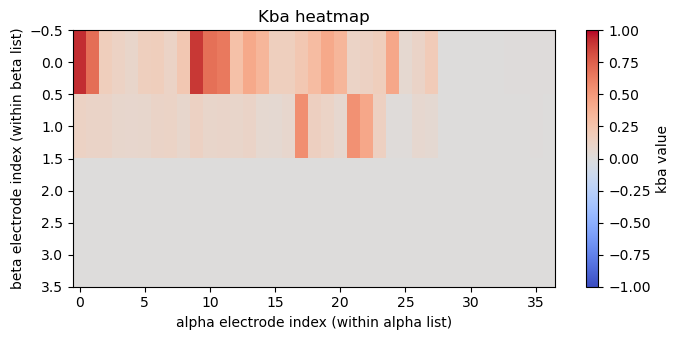

In [39]:
plt.figure(figsize=(7, 3.5))
plt.imshow(Kba, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(label='kba value')
plt.xlabel('alpha electrode index (within alpha list)')
plt.ylabel('beta electrode index (within beta list)')
plt.title('Kba heatmap')
plt.tight_layout()
plt.show()


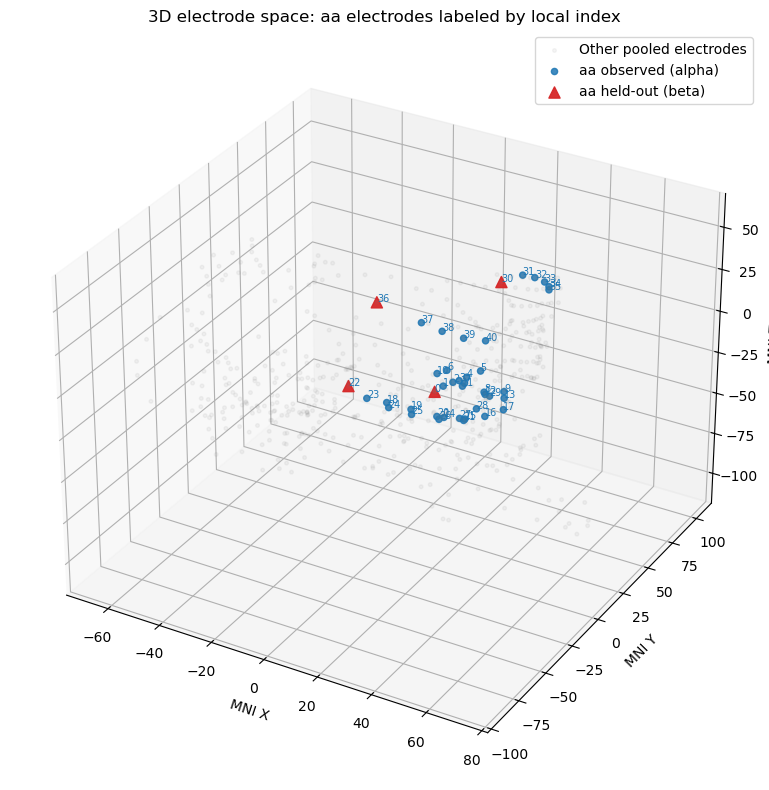

In [40]:
coords = np.asarray(all_electrodes, dtype=float)
aa_coords = subject_records[holdout_pid]['locs']

plt.figure(figsize=(8, 8))
ax = plt.axes(projection='3d')
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], s=7, alpha=0.08, color='gray', label='Other pooled electrodes')
ax.scatter(aa_coords[alpha_local_idx, 0], aa_coords[alpha_local_idx, 1], aa_coords[alpha_local_idx, 2], s=20, alpha=0.85, color='tab:blue', label='aa observed (alpha)')
ax.scatter(aa_coords[beta_local_idx, 0], aa_coords[beta_local_idx, 1], aa_coords[beta_local_idx, 2], s=65, marker='^', alpha=0.95, color='tab:red', label='aa held-out (beta)')

for i in range(aa_coords.shape[0]):
    ax.text(aa_coords[i, 0], aa_coords[i, 1], aa_coords[i, 2], str(i), fontsize=7, color='tab:blue')

ax.set_xlabel('MNI X')
ax.set_ylabel('MNI Y')
ax.set_zlabel('MNI Z')
ax.set_title('3D electrode space: aa electrodes labeled by local index')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


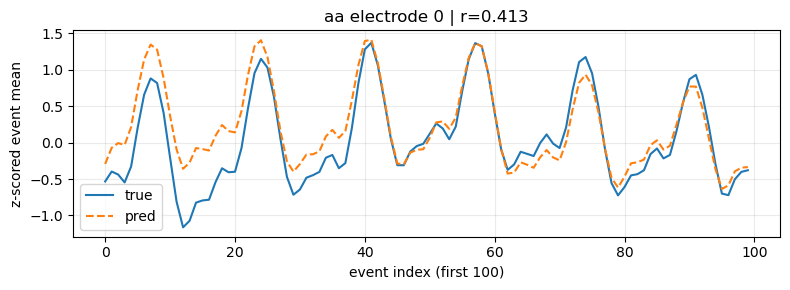

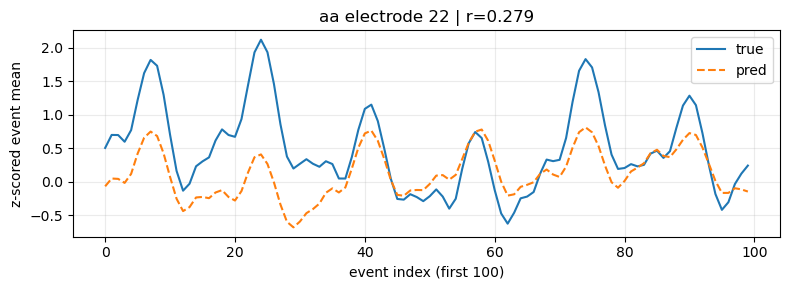

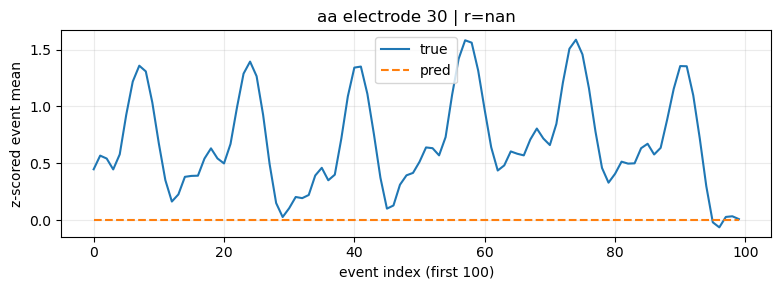

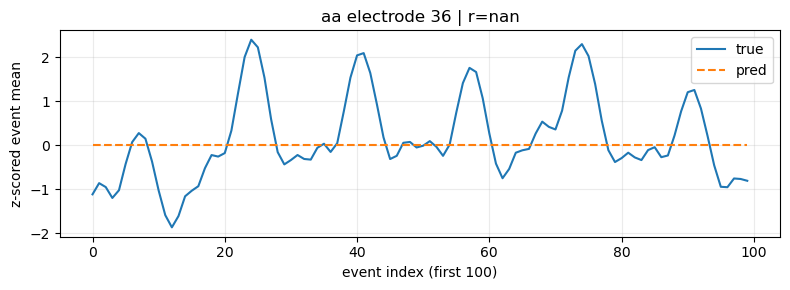

In [41]:
n_show = min(100, Y_beta_true.shape[0])
for j in range(Y_beta_true.shape[1]):
    rj = safe_corr(Y_beta_true[:, j], Y_beta_pred[:, j])
    plt.figure(figsize=(8, 3))
    plt.plot(np.arange(n_show), Y_beta_true[:n_show, j], label='true')
    plt.plot(np.arange(n_show), Y_beta_pred[:n_show, j], label='pred', linestyle='--')
    plt.title(f'{holdout_pid} electrode {int(beta_local_idx[j])} | r={rj:.3f}')
    plt.xlabel('event index (first 100)')
    plt.ylabel('z-scored event mean')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
